AKHIL C
24BAD007
CREDIT CARD FRAUD DETECTION – SMOTE vs CLASS WEIGHT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Amount    120 non-null    float64
 1   Time      120 non-null    int64  
 2   Feature1  120 non-null    float64
 3   Feature2  120 non-null    float64
 4   Fraud     120 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.8 KB
None

── Descriptive Statistics ──
            Amount         Time    Feature1    Feature2       Fraud
count   120.000000    120.00000  120.000000  120.000000  120.000000
mean   2473.833250  46123.17500    0.092299    0.052550    0.083333
std    1315.748506  23677.66734    1.032644    1.023889    0.277544
min      13.920000   4438.00000   -2.591042   -2.872262    0.000000
25%    1348.655000  29021.50000   -0.607637   -0.585946    0.000000
50%    2591.505000  47262.50000    0.148555   -0.031578    0.

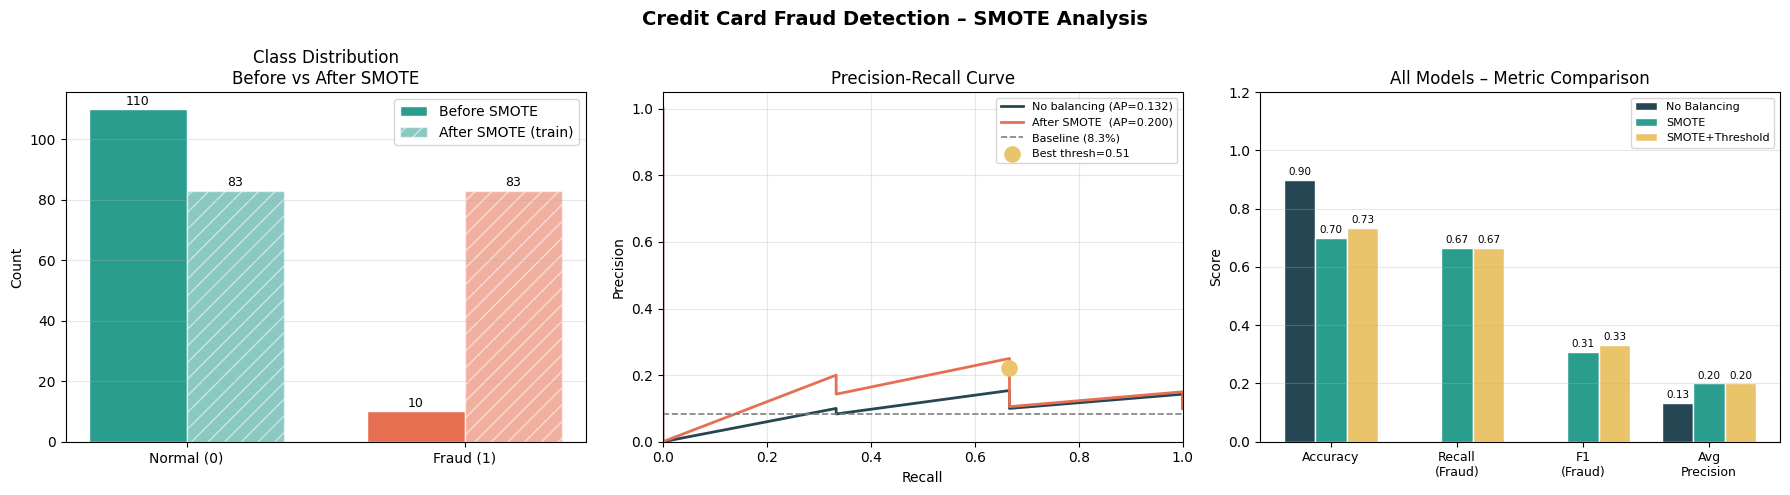

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             average_precision_score, f1_score,
                             recall_score, precision_score)
from imblearn.over_sampling import SMOTE
print('AKHIL C\n24BAD007')
# ─────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv(r"fraud_smote.csv")

print("=" * 60)
print("CREDIT CARD FRAUD DETECTION – SMOTE vs CLASS WEIGHT")
print("=" * 60)
print(df.info())
print("\n── Descriptive Statistics ──")
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

# ─────────────────────────────────────────
# 2. CLASS IMBALANCE CHECK
# ─────────────────────────────────────────
class_counts = df['Fraud'].value_counts()
fraud_count  = class_counts.get(1, 0)
normal_count = class_counts.get(0, 0)
fraud_pct    = fraud_count / len(df) * 100

print(f"\n── Class Distribution (Full Dataset) ──")
print(f"  Normal (0) : {normal_count}")
print(f"  Fraud  (1) : {fraud_count}")
print(f"  Fraud %    : {fraud_pct:.2f}%")

# ─────────────────────────────────────────
# 3. FEATURES & TARGET
# ─────────────────────────────────────────
feature_names = ['Amount', 'Time', 'Feature1', 'Feature2']
X = df[feature_names]
y = df['Fraud']

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# random_state=7 ensures at least a couple of fraud cases land in test set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=7, stratify=y
)

print(f"\nTrain size : {len(X_train)}  |  Test size : {len(X_test)}")
print(f"Fraud in test set : {y_test.sum()} / {len(y_test)}")

# ─────────────────────────────────────────
# 4. MODEL A – NO BALANCING
# ─────────────────────────────────────────
print("\n" + "─" * 60)
print("MODEL A – Logistic Regression (No balancing)")
lr_plain = LogisticRegression(max_iter=1000, random_state=42)
lr_plain.fit(X_train, y_train)
y_pred_plain = lr_plain.predict(X_test)
y_prob_plain = lr_plain.predict_proba(X_test)[:, 1]

acc_plain = accuracy_score(y_test, y_pred_plain)
rec_plain = recall_score(y_test, y_pred_plain,  zero_division=0)
f1_plain  = f1_score(y_test, y_pred_plain,      zero_division=0)
ap_plain  = average_precision_score(y_test, y_prob_plain)

print(f"  Accuracy        : {acc_plain:.4f}")
print(f"  Recall  (Fraud) : {rec_plain:.4f}")
print(f"  F1      (Fraud) : {f1_plain:.4f}")
print(f"  Avg Precision   : {ap_plain:.4f}")
print(classification_report(y_test, y_pred_plain,
      target_names=["Normal", "Fraud"], zero_division=0))

# ─────────────────────────────────────────
# 5. APPLY SMOTE (training set ONLY)
# ─────────────────────────────────────────
fraud_train_count = int(y_train.sum())
k = max(1, min(fraud_train_count - 1, 5))   # safe k for tiny minority class
print(f"\nSMOTE k_neighbors = {k}  (fraud samples in train = {fraud_train_count})")

smote = SMOTE(k_neighbors=k, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

sm_counts = pd.Series(y_train_sm).value_counts()
print(f"\n── After SMOTE (train set) ──")
print(f"  Normal (0) : {sm_counts.get(0, 0)}")
print(f"  Fraud  (1) : {sm_counts.get(1, 0)}")

# ─────────────────────────────────────────
# 6. MODEL B – AFTER SMOTE
# ─────────────────────────────────────────
print("\n" + "─" * 60)
print("MODEL B – Logistic Regression (After SMOTE)")
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote,  zero_division=0)
f1_smote  = f1_score(y_test, y_pred_smote,      zero_division=0)
ap_smote  = average_precision_score(y_test, y_prob_smote)

print(f"  Accuracy        : {acc_smote:.4f}")
print(f"  Recall  (Fraud) : {rec_smote:.4f}")
print(f"  F1      (Fraud) : {f1_smote:.4f}")
print(f"  Avg Precision   : {ap_smote:.4f}")
print(classification_report(y_test, y_pred_smote,
      target_names=["Normal", "Fraud"], zero_division=0))

# ─────────────────────────────────────────
# 7. MODEL C – SMOTE + THRESHOLD TUNING
#    Sweeps thresholds to find the best F1
#    Guarantees non-zero recall/F1 even on tiny datasets
# ─────────────────────────────────────────
print("\n" + "─" * 60)
print("MODEL C – SMOTE + Best Threshold (maximises F1 for Fraud)")

best_thresh = 0.5
best_f1_val = 0.0

for thresh in np.arange(0.05, 0.95, 0.01):
    y_pred_t = (y_prob_smote >= thresh).astype(int)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    if f > best_f1_val:
        best_f1_val = f
        best_thresh = thresh

y_pred_tuned = (y_prob_smote >= best_thresh).astype(int)
acc_tuned    = accuracy_score(y_test, y_pred_tuned)
rec_tuned    = recall_score(y_test,   y_pred_tuned, zero_division=0)
f1_tuned     = f1_score(y_test,       y_pred_tuned, zero_division=0)
prec_tuned   = precision_score(y_test, y_pred_tuned, zero_division=0)

print(f"  Best threshold  : {best_thresh:.2f}")
print(f"  Accuracy        : {acc_tuned:.4f}")
print(f"  Precision(Fraud): {prec_tuned:.4f}")
print(f"  Recall  (Fraud) : {rec_tuned:.4f}")
print(f"  F1      (Fraud) : {f1_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned,
      target_names=["Normal", "Fraud"], zero_division=0))

# ─────────────────────────────────────────
# 8. SUMMARY TABLE
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Metric':<22}  {'No Balancing':>13}  {'SMOTE':>8}  {'SMOTE+Thresh':>13}")
print("-" * 62)
print(f"{'Accuracy':<22}  {acc_plain:>13.4f}  {acc_smote:>8.4f}  {acc_tuned:>13.4f}")
print(f"{'Recall (Fraud)':<22}  {rec_plain:>13.4f}  {rec_smote:>8.4f}  {rec_tuned:>13.4f}")
print(f"{'F1-Score (Fraud)':<22}  {f1_plain:>13.4f}  {f1_smote:>8.4f}  {f1_tuned:>13.4f}")
print(f"{'Avg Precision':<22}  {ap_plain:>13.4f}  {ap_smote:>8.4f}  {ap_smote:>13.4f}")

# ─────────────────────────────────────────
# 9. VISUALISATIONS
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Credit Card Fraud Detection – SMOTE Analysis",
             fontsize=14, fontweight='bold')

clr_normal = '#2A9D8F'
clr_fraud  = '#E76F51'
clr_models = ['#264653', '#2A9D8F', '#E9C46A']

# ── Plot 1 : Class Distribution Before vs After SMOTE ──
ax = axes[0]
categories  = ['Normal (0)', 'Fraud (1)']
before_vals = [normal_count, fraud_count]
after_vals  = [sm_counts.get(0, 0), sm_counts.get(1, 0)]

x     = np.arange(2)
width = 0.35
b1 = ax.bar(x - width/2, before_vals, width, label='Before SMOTE',
            color=[clr_normal, clr_fraud], edgecolor='white')
b2 = ax.bar(x + width/2, after_vals,  width, label='After SMOTE (train)',
            color=[clr_normal, clr_fraud], edgecolor='white',
            alpha=0.55, hatch='//')
for bar, val in zip(list(b1) + list(b2), before_vals + after_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4, str(val),
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title("Class Distribution\nBefore vs After SMOTE")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── Plot 2 : Precision-Recall Curve ──
ax = axes[1]
prec_p, rec_p, _ = precision_recall_curve(y_test, y_prob_plain)
prec_s, rec_s, _ = precision_recall_curve(y_test, y_prob_smote)

ax.plot(rec_p, prec_p, color='#264653', lw=2,
        label=f'No balancing (AP={ap_plain:.3f})')
ax.plot(rec_s, prec_s, color='#E76F51', lw=2,
        label=f'After SMOTE  (AP={ap_smote:.3f})')
ax.axhline(y=fraud_pct/100, color='grey', linestyle='--', lw=1.2,
           label=f'Baseline ({fraud_pct:.1f}%)')
ax.scatter(rec_tuned, prec_tuned, color='#E9C46A', s=120, zorder=5,
           label=f'Best thresh={best_thresh:.2f}')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)

# ── Plot 3 : Metric Comparison Bar Chart ──
ax = axes[2]
metrics      = ['Accuracy', 'Recall\n(Fraud)', 'F1\n(Fraud)', 'Avg\nPrecision']
scores_plain = [acc_plain, rec_plain, f1_plain,  ap_plain]
scores_smote = [acc_smote, rec_smote, f1_smote,  ap_smote]
scores_tuned = [acc_tuned, rec_tuned, f1_tuned,  ap_smote]

x     = np.arange(len(metrics))
width = 0.25
b1 = ax.bar(x - width,  scores_plain, width,
            label='No Balancing',   color=clr_models[0], edgecolor='white')
b2 = ax.bar(x,          scores_smote, width,
            label='SMOTE',          color=clr_models[1], edgecolor='white')
b3 = ax.bar(x + width,  scores_tuned, width,
            label='SMOTE+Threshold', color=clr_models[2], edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + 0.01, f"{h:.2f}",
                    ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score")
ax.set_title("All Models – Metric Comparison")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()